# Task #3: EDA and Training Data Profile

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json

## Loaded the normalized tables + frozen split


In [84]:
DATA_DIR = "split_data"           # same folder frozen_train.ipynb reads from
SPLIT_DIR = "frozen-split_data"   # where frozen_train.ipynb wrote the split map
OUTPUT_DIR = Path("task3_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

contracts = pd.read_parquet(f"{DATA_DIR}/contracts.parquet")
documents = pd.read_parquet(f"{DATA_DIR}/documents.parquet")
categories = pd.read_parquet(f"{DATA_DIR}/categories.parquet")
annotation_sets = pd.read_parquet(f"{DATA_DIR}/annotation_sets.parquet")
spans = pd.read_parquet(f"{DATA_DIR}/spans.parquet")
split_map = pd.read_parquet(f"{SPLIT_DIR}/frozen-split.parquet")

print("contracts:", contracts.shape)
print("documents:", documents.shape)
print("categories:", categories.shape)
print("annotation_sets:", annotation_sets.shape)
print("spans:", spans.shape)
print("split_map:", split_map.shape)

contracts: (408, 2)
documents: (408, 4)
categories: (41, 3)
annotation_sets: (16728, 4)
spans: (11180, 6)
split_map: (407, 2)


## Train Split


In [85]:
documents = documents.merge(split_map, on="context_group_id", how="left")

# each document should have a split label
unmatched = documents["split"].isna().sum()
print(f"documents with NO split label (should be 0): {unmatched}")

train_documents = documents[documents["split"] == "train"].copy()
train_contract_ids = set(train_documents["contract_id"])

train_contracts = contracts[contracts["contract_id"].isin(train_contract_ids)].copy()
train_annotation_sets = annotation_sets[annotation_sets["contract_id"].isin(train_contract_ids)].copy()
train_spans = spans[spans["annotation_set_id"].isin(train_annotation_sets["annotation_set_id"])].copy()

print(f"train contracts:{len(train_contracts)}")
print(f"train documents:{len(train_documents)}")
print(f"train annotation sets:{len(train_annotation_sets)}")
print(f"train spans:{len(train_spans)}")

# anomaly
# context_group_id is not contract_id. This is the split unit: duplicates

groups_with_multiple_contracts = (
    train_documents.groupby("context_group_id")["contract_id"].nunique() > 1
).sum()
print(f"train context groups shared by >1 contract (expected/by design): {groups_with_multiple_contracts}")

documents with NO split label (should be 0): 0
train contracts:325
train documents:325
train annotation sets:13325
train spans:8964
train context groups shared by >1 contract (expected/by design): 1


# 1. Contract / document length statistics

Character count and word count are exact. Token count is only an estimate for now.
(legal English averages roughly 4.5 characters per token) -- good enough for EDA;
Note: A "4.5 character token" is the standard rule of thumb used in Natural Language Processing (NLP) to estimate the relationship between text length and token count for English text.

In [86]:
train_documents["char_length"] = train_documents["context"].str.len()
train_documents["word_count"] = train_documents["context"].str.split().str.len()
train_documents["approx_token_count"] = (train_documents["char_length"] / 4.5).round().astype(int)

length_stats = train_documents[["char_length", "word_count", "approx_token_count"]].describe(
    percentiles=[.10, .25, .5, .75, .90, .95, .99]
)
length_stats.to_csv(OUTPUT_DIR / "document_length_stats.csv")
length_stats

,char_length,word_count,approx_token_count
count,325.000000,325.000000,325.000000
mean,53164.753846,7927.646154,11814.378462
std,55677.136157,8194.681159,12372.673974
min,1081.000000,170.000000,240.000000
10%,6180.800000,925.600000,1373.400000
25%,16509.000000,2500.000000,3669.000000
50%,35612.000000,5326.000000,7914.000000
75%,67932.000000,10256.000000,15096.000000
90%,126975.200000,18733.600000,28216.800000
95%,162884.400000,25326.000000,36196.200000


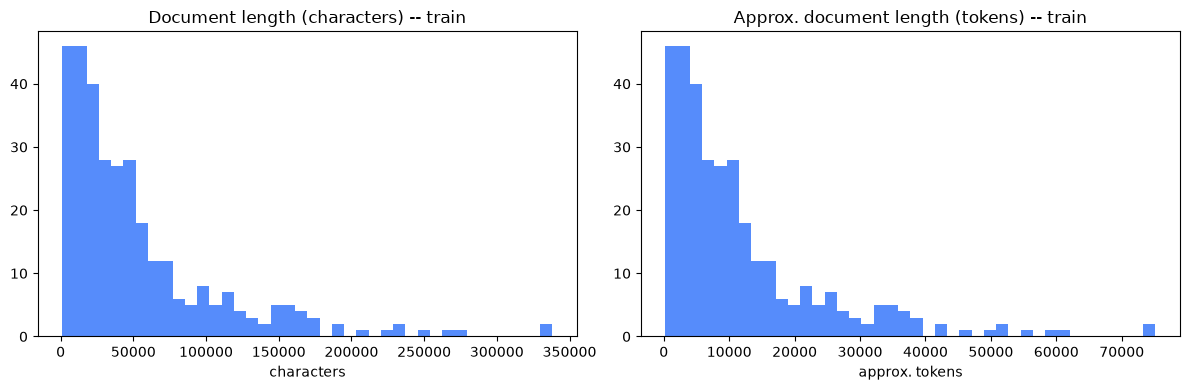

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train_documents["char_length"], bins=40)
axes[0].set_title("Document length (characters) -- train")
axes[0].set_xlabel("characters")

axes[1].hist(train_documents["approx_token_count"], bins=40)
axes[1].set_title("Approx. document length (tokens) -- train")
axes[1].set_xlabel("approx. tokens")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "document_length_hist.png", dpi=150)
plt.show()

## 2. Category support

For each of the 41 categories: how many train contracts actually have a positive (non-impossible) answer? This leads into Task #5 -- categories with almost no support are risky to pick as one of the final 10.

In [88]:
positive_train = train_annotation_sets[train_annotation_sets["is_impossible"] == False]

category_support = (
    positive_train.groupby("category_id")["contract_id"]
    .nunique()
    .reset_index(name="num_supporting_contracts")
    .merge(categories[["category_id", "category_name"]], on="category_id", how="right")  # keep all 41, even zero-support ones
    .fillna({"num_supporting_contracts": 0})
    .sort_values("num_supporting_contracts", ascending=False)
    .reset_index(drop=True)
)
category_support["num_supporting_contracts"] = category_support["num_supporting_contracts"].astype(int)

category_support.to_csv(OUTPUT_DIR / "category_support.csv", index=False)
category_support

,category_id,num_supporting_contracts,category_name
0,document_name,325,Document Name
1,parties,324,Parties
2,agreement_date,300,Agreement Date
3,governing_law,274,Governing Law
4,expiration_date,263,Expiration Date
5,effective_date,253,Effective Date
6,anti_assignment,235,Anti-Assignment
7,cap_on_liability,184,Cap On Liability
8,license_grant,163,License Grant
9,audit_rights,139,Audit Rights


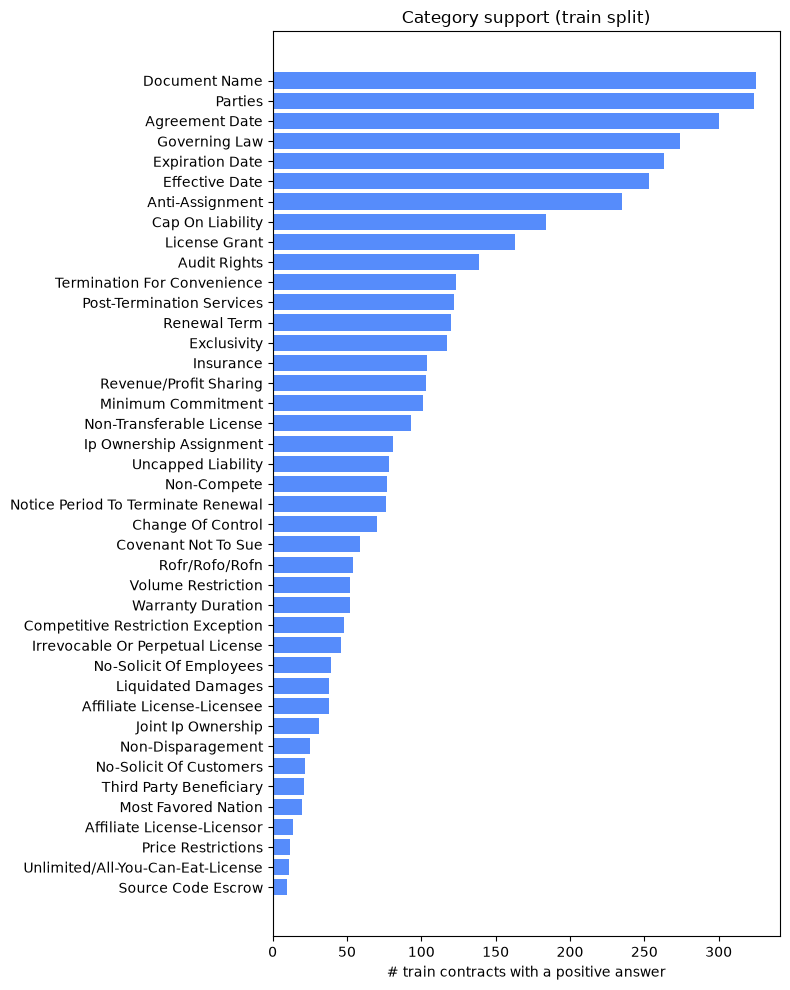

In [89]:
fig, ax = plt.subplots(figsize=(8, 10))
ax.barh(category_support["category_name"], category_support["num_supporting_contracts"])
ax.invert_yaxis()
ax.set_xlabel("# train contracts with a positive answer")
ax.set_title("Category support (train split)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "category_support.png", dpi=150)
plt.show()

## 3. Category co-occurrence

Which categories tend to show up together in the same contract? Useful for Task #6
when you're justifying why two categories got bundled together (or deliberately NOT
bundled).

In [90]:
# one row per (contract_id, category_id) that has a positive answer
presence = positive_train[["contract_id", "category_id"]].drop_duplicates()

# contract x category 0/1 matrix, keeping all 41 category columns even if some have zero train support
presence_matrix = (
    presence.assign(present=1)
    .pivot_table(index="contract_id", columns="category_id", values="present", fill_value=0)
    .reindex(columns=categories["category_id"], fill_value=0)
)

# cooccurrence[i, j] = number of contracts where category i AND category j both appear
cooccurrence = presence_matrix.T.dot(presence_matrix)
cooccurrence.to_csv(OUTPUT_DIR / "category_cooccurrence.csv")

cooccurrence.iloc[:8, :8]  # it's 41x41 -- just peeking at a corner here

category_id,document_name,parties,agreement_date,effective_date,expiration_date,renewal_term,notice_period_to_terminate_renewal,governing_law
category_id,,,,,,,,
document_name,325.0,324.0,300.0,253.0,263.0,120.0,76.0,274.0
parties,324.0,324.0,300.0,253.0,263.0,120.0,76.0,273.0
agreement_date,300.0,300.0,300.0,239.0,246.0,112.0,73.0,258.0
effective_date,253.0,253.0,239.0,253.0,224.0,105.0,68.0,230.0
expiration_date,263.0,263.0,246.0,224.0,263.0,117.0,75.0,243.0
renewal_term,120.0,120.0,112.0,105.0,117.0,120.0,76.0,114.0
notice_period_to_terminate_renewal,76.0,76.0,73.0,68.0,75.0,76.0,76.0,73.0
governing_law,274.0,273.0,258.0,230.0,243.0,114.0,73.0,274.0


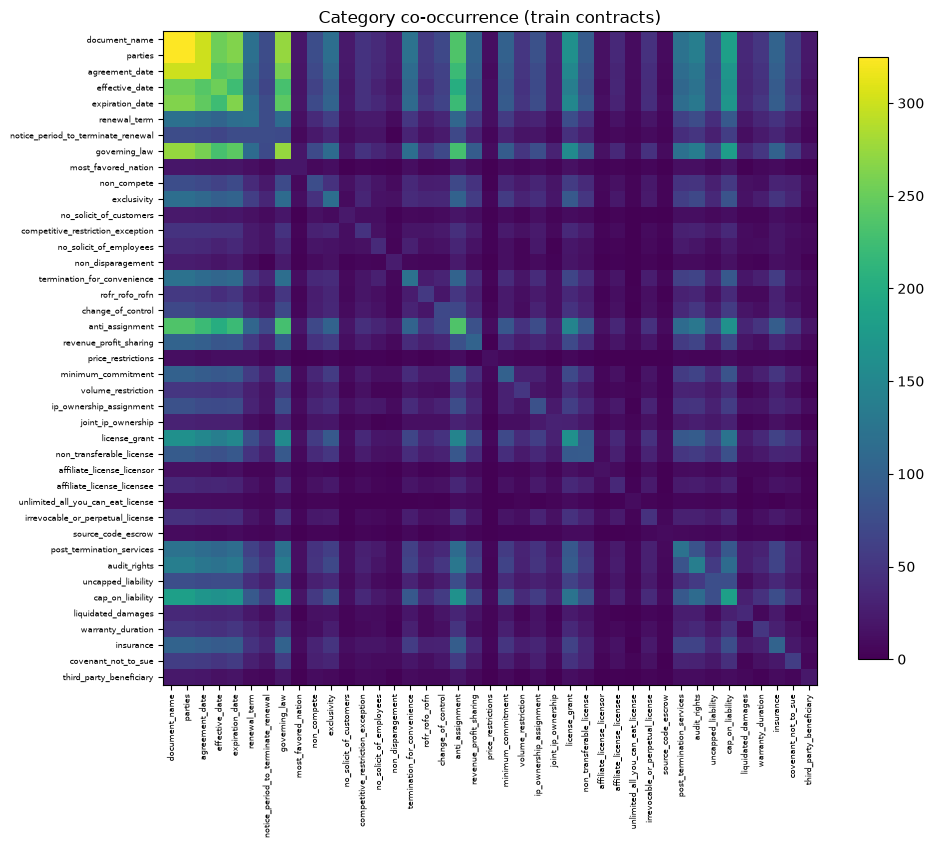

In [91]:
fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(cooccurrence.values, cmap="viridis")
ax.set_xticks(range(len(cooccurrence.columns)))
ax.set_xticklabels(cooccurrence.columns, rotation=90, fontsize=6)
ax.set_yticks(range(len(cooccurrence.index)))
ax.set_yticklabels(cooccurrence.index, fontsize=6)
ax.set_title("Category co-occurrence (train contracts)")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "category_cooccurrence.png", dpi=150)
plt.show()

## 4. Annotation density

How much evidence exists per contract / per annotation set / per 1,000 characters of text?
High density = plenty to learn from; low density = sparse, harder category.

In [92]:
spans_per_set = (
    train_spans.groupby("annotation_set_id").size().reset_index(name="num_spans")
)

positive_categories_per_contract = (
    positive_train.groupby("contract_id")["category_id"].nunique()
    .reset_index(name="num_positive_categories")
)

spans_per_contract = (
    train_spans.merge(train_annotation_sets[["annotation_set_id", "contract_id"]], on="annotation_set_id")
    .groupby("contract_id").size().reset_index(name="num_spans")
)
density = spans_per_contract.merge(
    train_documents[["contract_id", "char_length"]].drop_duplicates("contract_id"),
    on="contract_id", how="left"
)
density["spans_per_1000_chars"] = density["num_spans"] / (density["char_length"] / 1000)

density_summary = pd.DataFrame({
    "avg_spans_per_annotation_set": [spans_per_set["num_spans"].mean()],
    "avg_positive_categories_per_contract": [positive_categories_per_contract["num_positive_categories"].mean()],
    "avg_spans_per_1000_chars": [density["spans_per_1000_chars"].mean()],
})
density_summary.to_csv(OUTPUT_DIR / "annotation_density_summary.csv", index=False)
density_summary

,avg_spans_per_annotation_set,avg_positive_categories_per_contract,avg_spans_per_1000_chars
0,2.076442,13.283077,0.930526


## 5. Chunking-relevant statistics

In [93]:
CHUNK_SIZE = 512
CHUNK_OVERLAP = 128
STEP = CHUNK_SIZE - CHUNK_OVERLAP  # how far the window slides each time

train_documents["num_chunks_est"] = np.ceil(
    (train_documents["approx_token_count"] - CHUNK_OVERLAP) / STEP
).clip(lower=1).astype(int)

chunk_stats = train_documents["num_chunks_est"].describe()

train_spans_len = train_spans.copy()
train_spans_len["approx_span_tokens"] = (
    (train_spans_len["answer_end"] - train_spans_len["answer_start"]) / 4.5
).round().astype(int)

num_spans_over_chunk = int((train_spans_len["approx_span_tokens"] > CHUNK_SIZE).sum())

chunking_summary = pd.DataFrame({
    "metric": ["avg_chunks_per_doc", "max_chunks_per_doc",
               "spans_longer_than_one_chunk", "pct_spans_longer_than_one_chunk"],
    "value": [
        chunk_stats["mean"],
        chunk_stats["max"],
        num_spans_over_chunk,
        round(100 * num_spans_over_chunk / len(train_spans_len), 2),
    ]
})
chunking_summary.to_csv(OUTPUT_DIR / "chunking_stats.csv", index=False)
chunking_summary

,metric,value
0,avg_chunks_per_doc,30.916923
1,max_chunks_per_doc,196.000000
2,spans_longer_than_one_chunk,11.000000
3,pct_spans_longer_than_one_chunk,0.120000


## 6. Anomaly log

Each check below logs a count of a specific problem. `0` is good. Anything nonzero
needs a decision in Task #4 about whether it blocks moving forward.

In [94]:
anomalies = []

def log_anomaly(check_name, count, detail=""):
    anomalies.append({"check": check_name, "count": int(count), "detail": detail})

# (1) span text doesn't actually match the contract text at its recorded offset
check_df = (
    train_spans
    .merge(train_annotation_sets[["annotation_set_id", "contract_id"]], on="annotation_set_id")
    .merge(train_documents[["contract_id", "context"]], on="contract_id")
)
mismatches = check_df.apply(
    lambda r: r["context"][r["answer_start"]:r["answer_end"]] != r["answer_text"], axis=1
)
log_anomaly("span_text_offset_mismatch", mismatches.sum(),
            "context[answer_start:answer_end] != answer_text")

# (2) impossible/out-of-range offsets
bad_offsets = (train_spans["answer_start"] < 0) | (train_spans["answer_end"] < train_spans["answer_start"])
log_anomaly("span_bad_offset", bad_offsets.sum(), "negative or inverted start/end index")

# (3) annotation set marked impossible but still has spans attached
impossible_with_spans = train_annotation_sets[
    train_annotation_sets["is_impossible"]
    & train_annotation_sets["annotation_set_id"].isin(train_spans["annotation_set_id"])
]
log_anomaly("impossible_but_has_spans", len(impossible_with_spans))

# (4) annotation set marked answerable but has NO spans attached
answerable_no_spans = train_annotation_sets[
    (~train_annotation_sets["is_impossible"])
    & (~train_annotation_sets["annotation_set_id"].isin(train_spans["annotation_set_id"]))
]
log_anomaly("answerable_but_no_spans", len(answerable_no_spans))

# (5) suspiciously short contract text (possible parsing issue)
short_docs = train_documents[train_documents["char_length"] < 200]
log_anomaly("suspiciously_short_document", len(short_docs), "context under 200 characters")

# (6) categories with almost no train support -- flagged for Task #5
low_support = category_support[category_support["num_supporting_contracts"] < 5]
log_anomaly("category_low_support_under_5", len(low_support),
            ", ".join(low_support["category_id"].tolist()))

anomaly_log = pd.DataFrame(anomalies)
anomaly_log.to_csv(OUTPUT_DIR / "anomaly_log.csv", index=False)
anomaly_log

,check,count,detail
0,span_text_offset_mismatch,0,context[answer_start:answer_end] != answer_text
1,span_bad_offset,0,negative or inverted start/end index
2,impossible_but_has_spans,0,
3,answerable_but_no_spans,0,
4,suspiciously_short_document,0,context under 200 characters
5,category_low_support_under_5,0,


## Wrap-up

One JSON summary so Task #4 (Gate 1 Verification) can pull these numbers in as machine-readable evidence.

In [95]:
profile_summary = {
    "split": "train",
    "num_contracts": len(train_contracts),
    "num_documents": len(train_documents),
    "num_annotation_sets": len(train_annotation_sets),
    "num_spans": len(train_spans),
    "doc_length_char_mean": float(train_documents["char_length"].mean()),
    "doc_length_char_median": float(train_documents["char_length"].median()),
    "anomaly_total": int(anomaly_log["count"].sum()),
}

with open(OUTPUT_DIR / "task3_profile_summary.json", "w") as f:
    json.dump(profile_summary, f, indent=2)

profile_summary

{'split': 'train',
 'num_contracts': 325,
 'num_documents': 325,
 'num_annotation_sets': 13325,
 'num_spans': 8964,
 'doc_length_char_mean': 53164.75384615385,
 'doc_length_char_median': 35612.0,
 'anomaly_total': 0}